In [2]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
def NE_dn(w, type='ave'): # Denoise the weight matrix
    # w: weight matrix (symmetric matrix, w.shape=(num_cells, num_cells)); type: denoise type, 'ave' or 'gph'
    D = np.sum(np.abs(w), axis=1) + 1e-20 # D: degree matrix, D.shape=(num_cells,)
    if type == 'ave': D_ = np.diag(1 / D); w_normal = np.dot(D_, w) # do the average denoise, wn = D^(-1) * w
    if type == 'gph': D_ = np.diag(1 / np.sqrt(D)); w_normal = np.dot(np.dot(D_, w), D_) # do the graph denoise (Graph Laplacian), wn = D^(-1/2) * w * D^(-1/2)
    return w_normal # shape: (num_cells, num_cells), w_normal is symmetric matrix if type is 'gph' and w_normal is not symmetric matrix if type is 'ave'

def TransitionFields(w): # TransitionFields method
    # w: weight matrix (w.shape=(num_cells, num_cells))
    zeroindex = np.argwhere(np.sum(w, axis=1) == 0).flatten() # zeroindex: cells with no connections, shape=(num_cells,)
    w = NE_dn(w, 'ave') # do the average denoise, shape: (num_cells, num_cells)
    w = w / np.sqrt(np.sum(np.abs(w), axis=0) + 1e-20).reshape(1, -1) # shape: (num_cells, num_cells), column-wise normalization
    w = np.dot(w, w.T) # W: transition matrix, shape: (num_cells, num_cells)
    w[zeroindex, :] = 0; w[:, zeroindex] = 0 # set the connections of cells with no connections to be zero
    return w # transition matrix, shape: (num_cells, num_cells)
    
def Dominateset(aff_matrix, NR_OF_KNN): # Dominateset method
    # aff_matrix: affinity matrix (aff_matrix.shape=(num_cells, num_cells)); NR_OF_KNN: number of neighbors
    A, B = np.sort(aff_matrix, axis=1)[:, ::-1], np.argsort(aff_matrix, axis=1)[:, ::-1] # A: values, A.shape=(num_cells, num_cells), B: indices, B.shape=(num_cells, num_cells)
    ind = np.tile(np.arange(len(aff_matrix)).reshape(-1, 1), (1, NR_OF_KNN)) ; loc = B[:, :NR_OF_KNN] # shape: (num_cells, NR_OF_KNN)
    PNN_matrix = np.zeros(aff_matrix.shape); PNN_matrix[ind, loc] = A[:, :NR_OF_KNN]; PNN_matrix = (PNN_matrix + PNN_matrix.T) / 2
    return PNN_matrix # PNN_matrix: affinity matrix, remove the elements that are not the top NR_OF_KNN largest values in each row

def NetworkEnhancement(w_in, order, K, alpha):
    # Network Enhancement (NE) method. 
    # reference: https://www.nature.com/articles/s41467-018-05469-x, https://snap.stanford.edu/ne/, https://github.com/wangboyunze/Network_Enhancement
    w_temp = w_in * (1 - np.eye(len(w_in))) # weight matrix, shape=(num_cells, num_cells), remove the diagonal elements
    nonzeroindex = np.argwhere(np.sum(w_temp, axis=1) > 0).flatten() # zeroindex: cells with no connections, shape=(num_cells,)
    w_nonzero = w_in[nonzeroindex, :][:, nonzeroindex] # remove the cells with no connections
    DD = np.sum(np.abs(w_nonzero), axis=0) # DD: degree matrix, DD.shape=(num_cells_nonzero,)
    w_nonzero = NE_dn(w_nonzero, type='ave'); w_nonzero = (w_nonzero + w_nonzero.T) / 2
    P = (Dominateset(np.abs(w_nonzero), min(K, len(w_nonzero) - 1))) * np.sign(w_nonzero)
    P = P + np.eye(len(P)) + np.diag(np.sum(np.abs(P.T), axis=0))
    P = TransitionFields(P); D, U = np.linalg.eig(P) # D: eigenvalues, D.shape=(num_cells_nonzero,), U: eigenvectors, U.shape=(num_cells_nonzero, num_cells_nonzero)
    d = D - 1e-20; d = (1 - alpha) * d / (1 - alpha * d ** order); D = np.diag(d)
    w_nonzero = np.dot(np.dot(U, D), U.T); w_nonzero = (w_nonzero * (1 - np.eye(len(w_nonzero)))) / (1 - np.diag(w_nonzero))
    D = np.diag(DD); w_nonzero =np.dot(D, w_nonzero); w_nonzero[w_nonzero < 0] = 0; w_nonzero = (w_nonzero + w_nonzero.T) / 2
    w_out = np.zeros((len(w_in), len(w_in))); 
    w_out[np.ix_(nonzeroindex, nonzeroindex)] = w_nonzero
    return w_out # shape: (num_cells, num_cells)

In [5]:
# simulate 3 types of cells with different gene expression patterns
np.random.seed(100)
cell_type_1 = []
for i in range(5):
    sample = np.array([1, 0, 0]) + np.random.normal(0, 0.2, 3)
    sample = sample / np.linalg.norm(sample)
    cell_type_1.append(sample)
cell_type_1 = np.array(cell_type_1)
cell_type_2 = []
for i in range(5):
    sample = np.array([0, 1, 0]) + np.random.normal(0, 0.3, 3)
    sample = sample / np.linalg.norm(sample)
    cell_type_2.append(sample)
cell_type_2 = np.array(cell_type_2)
cell_type_3 = []
for i in range(5):
    sample = np.array([0, 0, 1]) + np.random.normal(0, 0.2, 3)
    sample = sample / np.linalg.norm(sample)
    cell_type_3.append(sample)
cell_type_3 = np.array(cell_type_3)
cell = np.concatenate((cell_type_1, cell_type_2, cell_type_3), axis=0)

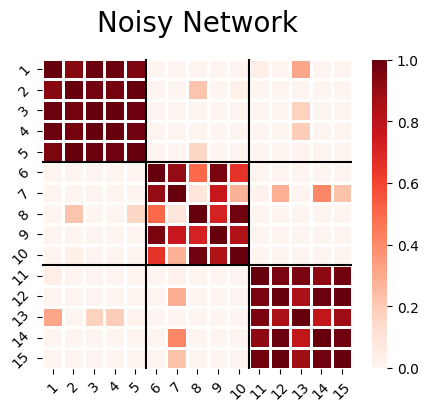

In [22]:
# Noisy Network
# adj = np.dot(cell, cell.T) / (np.linalg.norm(cell, axis=1).reshape(-1, 1) * np.linalg.norm(cell, axis=1)) # cosine similarity
adj = np.corrcoef(cell) # pearson correlation
adj[adj < 0] = 0
plt.figure(figsize=(5, 5))
# plt.imshow(adj, cmap='Reds', vmin=0, vmax=1)
sns.heatmap(adj, cmap='Reds', vmin=0, vmax=1, linewidths=1, linecolor='white', square=True, cbar=True, cbar_kws={'shrink': 0.8})
plt.xticks(np.arange(15)+0.5, np.arange(1, 16), rotation=45)
plt.yticks(np.arange(15)+0.5, np.arange(1, 16), rotation=45)
plt.axvline(5, color='black')
plt.axhline(5, color='black')
plt.axvline(10, color='black')
plt.axhline(10, color='black')
# plt.colorbar(shrink=0.8)
plt.title('Noisy Network', fontsize=20, color='black', loc='center', pad=20)
plt.show()

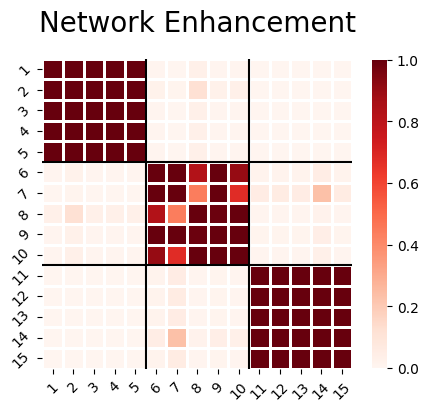

In [24]:
# Network Enhancement
adj_ne = NetworkEnhancement(adj, 2, 5, 0.5)
# adj_ne = NetworkEnhancement(adj_ne, 2, 5, 0.5)
# adj_ne = NetworkEnhancement(adj_ne, 2, 5, 0.5)
# adj_ne = NetworkEnhancement(adj_ne, 2, 5, 0.5)
# adj_ne = NetworkEnhancement(adj_ne, 2, 5, 0.5)
np.fill_diagonal(adj_ne, 1) # set the diagonal elements to be one
plt.figure(figsize=(5, 5))
# plt.imshow(adj_ne, cmap='Reds', vmin=0, vmax=1)
sns.heatmap(adj_ne, cmap='Reds', vmin=0, vmax=1, linewidths=1, linecolor='white', square=True, cbar=True, cbar_kws={'shrink': 0.8})
plt.xticks(np.arange(15)+0.5, np.arange(1, 16), rotation=45)
plt.yticks(np.arange(15)+0.5, np.arange(1, 16), rotation=45)
plt.axvline(5, color='black')
plt.axhline(5, color='black')
plt.axvline(10, color='black')
plt.axhline(10, color='black')
# plt.colorbar(shrink=0.8)
plt.title('Network Enhancement', fontsize=20, color='black', loc='center', pad=20)
plt.show()

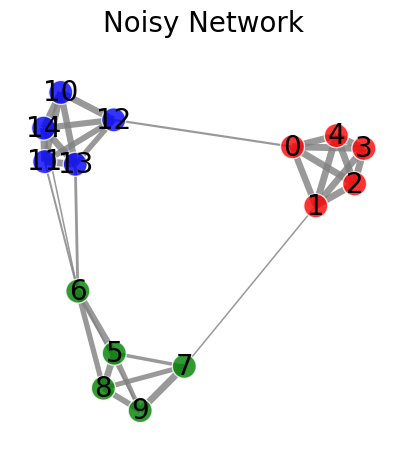

In [35]:
import networkx as nx
G = nx.Graph()
nodes = [(i, {'cell_type': 'cell_type_1', 'color': 'red'}) for i in range(5)] + \
        [(i, {'cell_type': 'cell_type_2', 'color': 'green'}) for i in range(5, 10)] + \
        [(i, {'cell_type': 'cell_type_3', 'color': 'blue'}) for i in range(10, 15)]
edges = [(i, j, {'weight': adj[i, j]}) for i in range(15) for j in range(i+1, 15) if adj[i, j] > 0.2]

for node, attr in nodes:
    G.add_node(node, **attr)

for u, v, attr in edges:
    G.add_edge(u, v, **attr)
    
pos = nx.spring_layout(G)
node_color = [attr['color'] for node, attr in G.nodes(data=True)]
edge_weight = [attr['weight'] * 5 for u, v, attr in G.edges(data=True)]
plt.figure(figsize=(5, 5))
# nx.draw(G, pos, with_labels=True, node_color=node_color, edge_color='gray', node_size=500, width=edge_weight)
nx.draw_networkx_nodes(G, pos, node_color=node_color, node_size=300, alpha=0.8, linewidths=1, edgecolors='white')
nx.draw_networkx_edges(G, pos, width=edge_weight, edge_color='gray', alpha=0.8)
nx.draw_networkx_labels(G, pos, font_size=20, font_color='black')
# delete the border of the plot
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.gca().spines['bottom'].set_visible(False)
plt.gca().spines['left'].set_visible(False)
plt.title('Noisy Network', fontsize=20, color='black', loc='center', pad=20)
plt.show()    